# Evolutionary Execution Researcher — Walkthrough (E0–E2)

This notebook demonstrates **every component** of the execution-evolution build in
isolation, on **synthetic data, fully offline** — no API key, no market data, no MCP
server (everything runs in-process under `QF_USE_MCP=0`).

**What the execution researcher is.** The factor researcher evolves *alpha programs*
(signals). Everything downstream — how a composite signal becomes a target book —
was hardcoded in two divergent pipelines. The execution researcher applies the same
FunSearch recipe one level up: **the LLM mutates `BaseExecutor` programs (the
signal→book code); a deterministic, cost-aware harness scores them**. The LLM never
influences its own reward.

| Layer | Component | Where |
| --- | --- | --- |
| E0 | `BaseExecutor` contract, seeds, causal state, `BookState` | `quant_fund_agent/execution/base.py`, `seeds.py`, `state.py` |
| E0 | codegen validator + in-memory compile | `execution/codegen.py` |
| E0 | frozen evaluation signals (versioned artifact + poison audit) | `execution/signal_freeze.py` |
| E0 | deterministic fitness harness + causality probe | `research_eval/exec_harness.py` |
| E1 | param-jitter operator, evolution loop, resume, SOTA/rescore seams | `agents/execution_research/evolution/` |
| E2 | deterministic reflection briefs + LLM mutation prompts | `.../reflection.py`, `.../mutation.py` |

Design anchors: `docs/execution-evolution/DESIGN.md` (inner loop 2) and
`docs/joint-evolution/DESIGN.md` (the outer layer that will alternate factor and
execution blocks).


panel: 480 daily bars x 6 tickers  |  workdir: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/exec_walkthrough_aj47z5im


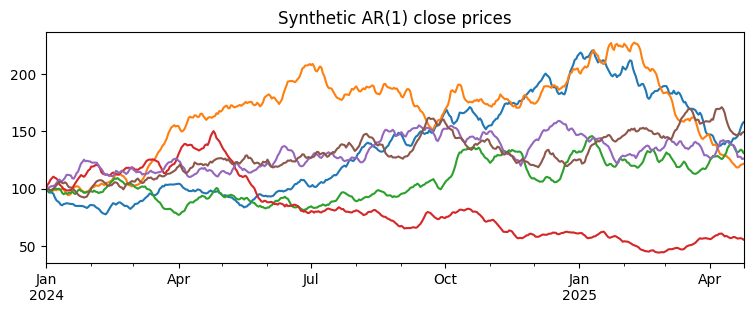

In [1]:
# ── setup: repo import path, synthetic AR(1) panel, in-process service wiring ──
import json, os, sys, tempfile, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))   # repo root when run from notebooks/
os.environ["QF_USE_MCP"] = "0"               # every MCP call runs in-process

# Synthetic panel: AR(1) returns (autocorr 0.6) → a 1-bar momentum signal has
# GENUINE predictive edge, so executors have something real to trade.
N_BARS, TICKERS = 480, ["A", "B", "C", "D", "E", "F"]
rng = np.random.default_rng(3)
rets = np.zeros((N_BARS, len(TICKERS)))
eps = rng.standard_normal((N_BARS, len(TICKERS))) * 0.01
for t in range(1, N_BARS):
    rets[t] = 0.6 * rets[t - 1] + eps[t]
idx = pd.date_range("2024-01-01", periods=N_BARS, freq="D")
close = pd.DataFrame(100 * np.cumprod(1 + rets, axis=0), index=idx, columns=TICKERS)
PANEL = {"close": close}

# Wire the research service's panel loader to our synthetic panel (the same seam
# the tests use) so freeze/evaluate calls below need no data on disk.
from quant_fund_agent.mcp import research_service as svc
svc._load_panel_cached = lambda data_dir, fields, n_tickers: PANEL
svc._panel_cache_key = lambda data_dir, fields, n_tickers: ("walkthrough-panel",)

WORKDIR = Path(tempfile.mkdtemp(prefix="exec_walkthrough_"))
print(f"panel: {close.shape[0]} daily bars x {close.shape[1]} tickers  |  workdir: {WORKDIR}")
close.plot(legend=False, title="Synthetic AR(1) close prices", figsize=(9, 3));


## 1. The genome: `BaseExecutor`

One evolution unit = one Python class with a declared contract:

* **`step(t, signal_row, state_row, book)`** — the canonical *stepwise* API: one
  bar's signal + causal state + **the executor's own current book** → target-weight
  row. Path-dependent logic (stops, profit-taking) is first-class because `book`
  carries positions, per-name unrealised P&L and the strategy's own drawdown.
* **`target_weights(signal, state)`** — an *optional vectorised fast-path* for
  path-independent programs; the harness uses it when implemented, else it drives
  `step` bar-by-bar.
* **`params = {...}`** — every tunable number, declared. This is the **jitter
  surface**: the mutation operator and the plateau probe both act on it.

**Genome #0 = the two deployed pipelines**, re-expressed as executors. The registry
versions (`execution/seeds.py`) *delegate* to the legacy functions — byte-equivalence
by construction; the evolution versions (self-contained source, next section) are
what the search actually mutates.


registered executors: ['topk_dollar_neutral', 'zscore_threshold_equal_weight']


byte-equivalence vs legacy pipelines: OK


,A,B,C,D,E,F
2025-04-22,0.166667,0.0,0.000000,0.000000,0.000000,0.0
2025-04-23,0.166667,0.0,0.000000,0.000000,-0.166667,0.0
2025-04-24,0.000000,0.0,-0.166667,-0.166667,0.000000,0.0


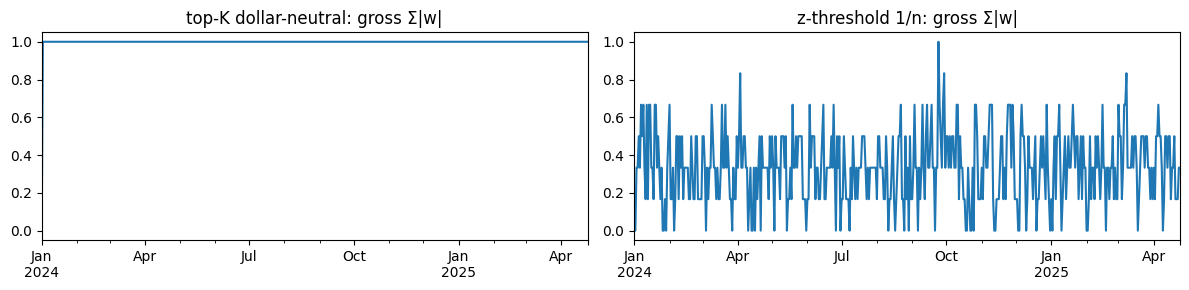

In [2]:
from quant_fund_agent.execution.base import (
    get_executor, list_executors, run_executor, validate_weights,
)
from quant_fund_agent.execution.state import build_state_frames

print("registered executors:", list_executors())

# a composite signal an Architect model might emit: 1-bar momentum (real edge here)
signal = close.pct_change().fillna(0.0)
state = build_state_frames(PANEL, signal)

topk = get_executor("topk_dollar_neutral")()
zthr = get_executor("zscore_threshold_equal_weight")()
w_topk = run_executor(topk, signal, state, close)
w_zthr = run_executor(zthr, signal, state, close)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
w_topk.abs().sum(axis=1).plot(ax=axes[0], title="top-K dollar-neutral: gross Σ|w|")
w_zthr.abs().sum(axis=1).plot(ax=axes[1], title="z-threshold 1/n: gross Σ|w|")
plt.tight_layout()

# byte-equivalence with the legacy hardcoded pipelines (the E0 guarantee)
from quant_fund_agent.backtesting.strategy_backtester import _signal_to_positions
from quant_fund_agent.backtesting.positions import per_underlying_positions
pd.testing.assert_frame_equal(w_topk, _signal_to_positions(signal))
pd.testing.assert_frame_equal(
    w_zthr, per_underlying_positions(signal, n_max_positions=6))
print("byte-equivalence vs legacy pipelines: OK")
w_zthr.tail(3)


## 2. Causal state frames

Executors condition on market context, but they must never compute it themselves —
the harness builds every state frame **causally** (trailing windows only), so input
causality is guaranteed by construction:

* `vol` — trailing volatility, `adv` — liquidity proxy, `drawdown` — per-name price
  drawdown from the running max, `signal_age` — bars since the signal last changed
  (the decay-aware-holding input). `spread` joins when the feed carries it.


{'vol': (480, 6),
 'adv': (480, 6),
 'drawdown': (480, 6),
 'signal_age': (480, 6)}

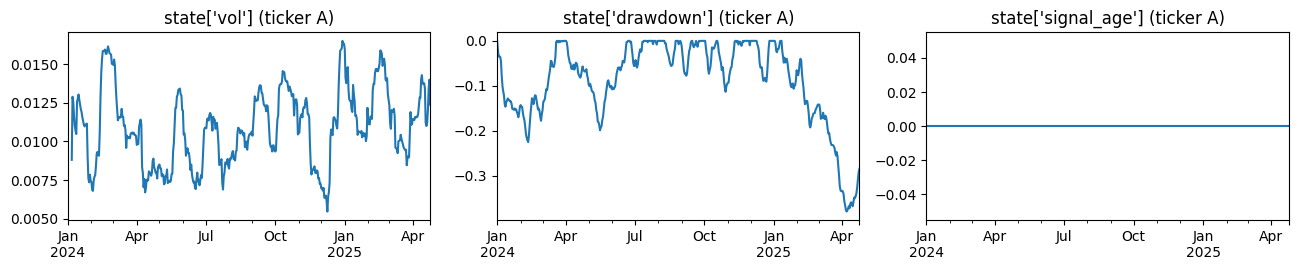

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8))
state["vol"]["A"].plot(ax=axes[0], title="state['vol'] (ticker A)")
state["drawdown"]["A"].plot(ax=axes[1], title="state['drawdown'] (ticker A)")
state["signal_age"]["A"].plot(ax=axes[2], title="state['signal_age'] (ticker A)")
plt.tight_layout()
{k: v.shape for k, v in state.items()}


## 3. Path dependence: `BookState` and the stepwise loop

The vectorised fast-path cannot express *"exit after my own position lost 5%"* —
weights at *t* would depend on the executor's own past outputs. The stepwise loop
maintains a `BookState` (marked to each bar's prices **before** `step` is called),
so a program can read its own positions, per-name unrealised P&L and running
drawdown. Below: a stop-loss overlay on the sign book — watch it flatten names whose
open position has lost more than the stop.


bars flattened by the stop-loss overlay: 5


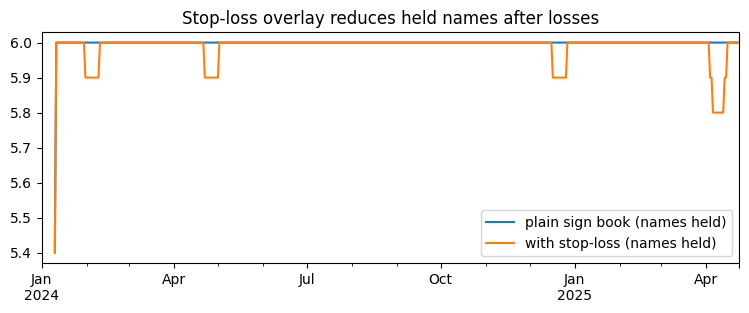

In [4]:
from quant_fund_agent.execution.base import BaseExecutor

class SignWithStopLoss(BaseExecutor):
    executor_id = "demo_sign_stoploss"
    regime = "per_underlying"
    params = {"n_max": 6, "stop_loss": 0.02}

    def step(self, t, signal_row, state_row, book):
        p = type(self).params
        target = np.sign(signal_row).fillna(0.0) / float(p["n_max"])
        # path dependence: a name whose OPEN position lost > stop stays flat
        stopped = book.unrealised_pnl < -float(p["stop_loss"]) / float(p["n_max"])
        return target.where(~stopped, 0.0)

w_stop = run_executor(SignWithStopLoss(), signal, state, close)
w_plain = np.sign(signal).fillna(0.0) / 6.0

flat_bars = ((w_stop == 0) & (w_plain != 0)).sum().sum()
print(f"bars flattened by the stop-loss overlay: {int(flat_bars)}")
pd.DataFrame({
    "plain sign book (names held)": (w_plain != 0).sum(axis=1),
    "with stop-loss (names held)": (w_stop != 0).sum(axis=1),
}).rolling(10).mean().plot(figsize=(9, 3), title="Stop-loss overlay reduces held names after losses");


## 4. The output contract — validated, never trusted

Hard bounds every candidate must satisfy (`validate_weights`): finite weights,
per-name |w| ≤ 1, gross Σ|w| ≤ 2, and ~dollar-neutrality for the `cross_sectional`
regime. `NaN` = "no position" (the seeds legitimately emit it before z-score
warm-up) — but `±inf` or bound breaches fail validity instantly.


In [5]:
demo = pd.DataFrame([[0.5, -0.5, np.nan, 0.0]], columns=list("ABCD"))
print("valid book:            ", validate_weights(demo, "cross_sectional"))
print("inf weight:            ", validate_weights(demo.replace(0.5, np.inf), "per_underlying"))
print("leverage breach:       ", validate_weights(demo * 3, "per_underlying"))
print("neutrality (cs only):  ", validate_weights(demo.abs(), "cross_sectional"))
print("same book, per-und.:   ", validate_weights(demo.abs(), "per_underlying"))


valid book:             []
inf weight:             ['non-finite (inf) weights']
leverage breach:        ['per-name bound breached: max |w|=1.5000 > 1.0', 'gross-leverage bound breached: max Σ|w|=3.0000 > 2.0']
neutrality (cs only):   ['dollar-neutrality violated: max |Σw|=1.0000 > tol=0.5']
same book, per-und.:    []


## 5. Freezing the K evaluation signals (the interface artifact)

The cross-signal generalisation axis scores every candidate against the **same K
frozen composite signals** (different model families × factor subsets) so no
executor can co-adapt to one alpha. Freezing is a *versioned artifact*:

* fits are **IS-only** (label-availability discipline included) on the
  **dev-sliced** panel (TEST physically absent);
* frames persist as parquet + a manifest (book hash, specs, window key, audit);
* `FrozenSignalSet.load()` always reads the parquet — consumers score exactly the
  artifact on disk;
* a **poison audit** runs at freeze time: corrupt every VAL row → the IS-row
  predictions must be bit-identical, proving the fit consumed nothing beyond IS.
  A leaky frozen signal would launder look-ahead into *every* executor score.


In [6]:
FACTOR_TMPL = '''\
# Walkthrough factor {fid}

from __future__ import annotations

import pandas as pd

from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.ops import ts_rank
from quant_fund_agent.factors.registry import register_factor


@register_factor
class F_{fid}(BaseFactor):
    factor_id = "{fid}"
    name = "{fid}"
    category = "momentum"
    inputs = ["close"]
    prediction_horizon = 1

    def calc(self, data: dict[str, pd.DataFrame]) -> pd.DataFrame:
        close = data["close"]
        return {body}
'''

BOOK = [
    {"factor_id": "wt_mom",  "code": FACTOR_TMPL.format(fid="wt_mom",  body="close.pct_change().fillna(0.0)")},
    {"factor_id": "wt_rank", "code": FACTOR_TMPL.format(fid="wt_rank", body="(ts_rank(close, 8) - 0.5).fillna(0.0)")},
]

frozen = svc.freeze_signals(
    BOOK, out_dir=str(WORKDIR), version=1, target_horizon=1,
    specs=[{"model": "ridge", "subset": [0, 1]}, {"model": "ridge", "subset": [0]}])
assert frozen["ok"], frozen.get("error")
MANIFEST_V1 = frozen["manifest_path"]
print(json.dumps({k: v for k, v in frozen["manifest"].items() if k != "signals"}, indent=2))
print("signal specs:", [ (s["model"], s["subset"]) for s in frozen["manifest"]["signals"] ])


{
  "version": 1,
  "k": 2,
  "target_horizon": 1,
  "book_hash": "5187eb5b65333da3",
  "book_ids": [
    "wt_mom",
    "wt_rank"
  ],
  "panel_window_key": [
    384,
    "2024-01-01 00:00:00",
    "2025-01-18 00:00:00",
    6
  ],
  "split_sizes": {
    "is": 288,
    "val": 96,
    "test": 0
  },
  "poison_audit": {
    "audited": true,
    "passed": true,
    "per_signal": [
      {
        "passed": true,
        "max_is_row_diff": 0.0,
        "model": "ridge"
      },
      {
        "passed": true,
        "max_is_row_diff": 0.0,
        "model": "ridge"
      }
    ]
  }
}
signal specs: [('ridge', ['wt_mom', 'wt_rank']), ('ridge', ['wt_mom'])]


### 5b. What the poison audit catches

Break the IS-only discipline on purpose — fit on **all** rows including VAL — and
the audit fails: poisoning VAL rows now changes the labels the fit saw, so the
IS-row predictions move.


In [7]:
from quant_fund_agent.execution import signal_freeze as sf
from quant_fund_agent.research_eval.splits import ThreeWaySplit, three_way_split

_real_combined = sf._combined
def _leaky_combined(signals, panel, is_mask, model, target_horizon):
    return _real_combined(signals, panel, np.ones(len(is_mask), dtype=bool),
                          model, target_horizon)   # fit on EVERYTHING → leak

full = three_way_split(close.index, is_frac=0.6, val_frac=0.2)
dev = full.is_val_mask
panel_dev = {"close": close.loc[dev]}
split_dev = ThreeWaySplit(full.is_mask[dev], full.val_mask[dev], full.test_mask[dev])

sf._combined = _leaky_combined
try:
    leaky = sf.freeze_eval_signals(BOOK, panel_dev, split_dev,
                                   out_dir=WORKDIR / "leaky", version=1,
                                   target_horizon=1,
                                   specs=[{"model": "ridge", "subset": [0, 1]}])
finally:
    sf._combined = _real_combined

print("clean freeze audit passed: ", frozen["manifest"]["poison_audit"]["passed"])
print("leaky freeze audit passed: ", leaky.poison_audit()["passed"])
print("leaky IS-row max diff:     ", leaky.poison_audit()["per_signal"][0]["max_is_row_diff"])


clean freeze audit passed:  True
leaky freeze audit passed:  False
leaky IS-row max diff:      0.050277469986209196


## 6. The deterministic fitness harness

`evaluate_executor` runs the program over each frozen signal through a cost-aware
book simulation and returns the standard `FitnessResult`. The five Pareto slots are
**re-mapped** (the dataclasses are reused verbatim so the controller/persistence
work unchanged):

| slot | execution meaning |
| --- | --- |
| `marginal_value` *(primary)* | mean **net-of-cost VAL Sharpe** across the K signals |
| `independence` | cross-signal generalisation `mean − λ·dispersion` |
| `robustness` | cost efficiency (net÷gross capture) |
| `parsimony` | −AST complexity |
| `structural_novelty` | min code distance to the nearest archived executor |

Gates: validity+min-activity (`coverage_ok`), IS→VAL net-Sharpe degradation
(`degradation_ok`), deflated Sharpe at the family `n_trials` (`deflation_ok`,
publish-time by default per WS1), and **turnover ceiling + the causality probe**
(`cost_ok`).

Conventions worth seeing once: the book is `weights.shift(1) × 1-bar forward
return` (the deployed convention), and the **last dev bar drops out of scoring** —
its forward return would need a TEST price.


In [8]:
from quant_fund_agent.execution.signal_freeze import FrozenSignalSet
from quant_fund_agent.research_eval.exec_harness import ExecEvalParams, evaluate_executor

frozen_frames = FrozenSignalSet.from_manifest(MANIFEST_V1).load()

res = evaluate_executor(
    get_executor("zscore_threshold_equal_weight")(),
    frozen_frames, panel_dev, split_dev,
    params=ExecEvalParams(), candidate_code="(seed)", candidate_id="seed_zthr")

print("objective:", json.dumps(res.objective.to_dict(), indent=2))
print("gates:    ", json.dumps(res.gates.to_dict(), indent=2))
print(f"last-bar drop: {res.diagnostics['per_signal'][0]['val_n_obs']} scored VAL bars "
      f"vs {int(split_dev.val_mask.sum())} VAL rows")
pd.DataFrame(res.diagnostics["per_signal"])


objective: {
  "marginal_value": 0.6079942934801791,
  "independence": 0.6065871175795801,
  "robustness": 0.9247085767344676,
  "parsimony": -0.0,
  "structural_novelty": null
}
gates:     {
  "coverage_ok": true,
  "degradation_ok": true,
  "deflation_ok": null,
  "cost_ok": true,
  "passed": true
}
last-bar drop: 95 scored VAL bars vs 96 VAL rows


,signal,is_net_sharpe,val_net_sharpe,val_gross_sharpe,val_n_obs,net_mean,gross_mean,capture,turnover,activity,cost_x0.5,cost_x1.5
0,0,0.633994,0.605180,0.655074,95,0.002084,0.002254,0.924490,0.357639,0.890625,0.630177,0.580097
1,1,0.630778,0.610809,0.661222,95,0.002075,0.002243,0.924927,0.356771,0.898438,0.636055,0.585496


## 7. The causality probe (truncation-replay)

An execution program can "win" by exploiting backtest artifacts — the classic one is
full-sample standardisation (look-ahead the static validator can't see). The probe
**re-runs the program on the panel physically truncated at bar t** and compares the
weight row at *t*: any dependence on the future moves it. Value perturbation can be
dodged; truncation-replay cannot.


In [9]:
from quant_fund_agent.research_eval.exec_harness import causality_probe

class FullSampleZ(BaseExecutor):          # the planted LEAK
    executor_id = "demo_leaky"
    regime = "per_underlying"
    def target_weights(self, signal, state):
        z = (signal - signal.mean()) / signal.std()      # full-sample stats!
        return z.clip(-1, 1).fillna(0.0) / signal.shape[1]

sig0 = frozen_frames[0].reindex(index=panel_dev["close"].index,
                                columns=panel_dev["close"].columns)
honest = causality_probe(get_executor("zscore_threshold_equal_weight")(), sig0, panel_dev)
leaky  = causality_probe(FullSampleZ(), sig0, panel_dev)
print("honest seed :", honest)
print("leaky       :", json.dumps(leaky, indent=2))

res_leaky = evaluate_executor(FullSampleZ(), frozen_frames, panel_dev, split_dev)
print("leaky executor cost_ok gate:", res_leaky.gates.cost_ok,
      "| reason:", res_leaky.gates.reasons.get("causality", "")[:80], "…")


honest seed : {'passed': True, 'points': [{'t': 128, 'max_diff': 0.0, 'ok': True}, {'t': 256, 'max_diff': 0.0, 'ok': True}]}
leaky       : {
  "passed": false,
  "points": [
    {
      "t": 128,
      "max_diff": 0.03657469423417274,
      "ok": false
    },
    {
      "t": 256,
      "max_diff": 0.013160064300438007,
      "ok": false
    }
  ]
}
leaky executor cost_ok gate: False | reason: truncation-replay mismatch: [{'t': 128, 'max_diff': 0.03657469423417274, 'ok': F …


## 8. The mutation operators (E1 + E2)

**Param jitter (deterministic, E1).** The `params` dict is the declared surface: the
operator AST-rewrites the dict literal (ints stay ints ≥ 1, floats scale). The same
transform at fixed ±10% gives the **plateau probe** — a program whose Sharpe
collapses under a param nudge sits on a knife-edge and its brief says so.


In [10]:
from quant_fund_agent.agents.execution_research.evolution.mutation import (
    jitter_params, jitter_variants, param_constants, random_jitter_child,
)
from quant_fund_agent.agents.execution_research.evolution.seeds import (
    ZTHRESH_SEED_CODE, seed_execution_programs,
)

print("parent params:", param_constants(ZTHRESH_SEED_CODE))
scaled, n = jitter_params(ZTHRESH_SEED_CODE, 1.5)
print(f"x1.5 jitter ({n} changed):", param_constants(scaled))

child = random_jitter_child(seed_execution_programs()[1],
                            np.random.default_rng(0), "ex_demo_child", pct=0.3)
print("jitter child params:", param_constants(child.code))
print("plateau probe ids:  ", [pid for pid, _ in jitter_variants(seed_execution_programs()[1])])


parent params: {'n_max_positions': 6.0, 'holding_period': 1.0, 'threshold': 1.0}
x1.5 jitter (3 changed): {'n_max_positions': 9.0, 'holding_period': 2.0, 'threshold': 1.5}
jitter child params: {'n_max_positions': 6.0, 'holding_period': 1.0, 'threshold': 0.7245841143617168}
plateau probe ids:   ['seed_zscore_threshold_jit0', 'seed_zscore_threshold_jit1']


**Reflection brief (deterministic, E2).** The harness's teacher-channel diagnostics
are rendered into a natural-language brief by **rules, not an LLM** — the reward
channel explaining itself. Each failure mode maps to targeted advice.


In [11]:
from quant_fund_agent.agents.execution_research.evolution.reflection import exec_mutation_brief

print("── brief for the PASSING seed ──")
print(exec_mutation_brief(res))
print()
print("── brief for the LEAKY executor ──")
print(exec_mutation_brief(res_leaky))


── brief for the PASSING seed ──
EXECUTION FITNESS for `seed_zthr` (PASSED all gates)
- mean net VAL Sharpe (per bar) across 2 frozen signal(s): 0.608 (IS: 0.632, dispersion across signals: 0.003)
- cost efficiency (net/gross capture): 0.925 | mean turnover/bar: 0.357 | active on 0.895 of bars
- per-signal net VAL Sharpe: s0=0.605(capture 0.92), s1=0.611(capture 0.92)
- cost sensitivity (signal 0): half costs → 0.630, 1.5× costs → 0.580
ADVICE:
  1. All gates passed. Improve the dominated axes: raise net Sharpe via state-conditional sizing (vol targeting, drawdown de-risking), or cut cost drag while keeping the capture ratio.

── brief for the LEAKY executor ──
EXECUTION FITNESS for `executor` (FAILED a gate)
- mean net VAL Sharpe (per bar) across 2 frozen signal(s): 0.718 (IS: 0.701, dispersion across signals: 0.003)
- cost efficiency (net/gross capture): 0.917 | mean turnover/bar: 0.515 | active on 1.000 of bars
- per-signal net VAL Sharpe: s0=0.720(capture 0.92), s1=0.715(capture 0.

**LLM-semantic mutation (E2).** The prompt = parent code + the deterministic brief +
the executor contract (state fields, causality warning, output bounds, allowed
imports). The response is JSON; nothing the LLM emits reaches evaluation without
passing the same static validator + synthetic smoke run as the persist path.
*(No API call here — we parse a canned response.)*


In [12]:
from quant_fund_agent.agents.execution_research.evolution.mutation import (
    build_exec_mutation_prompt, parse_exec_child_response,
)
from quant_fund_agent.execution.codegen import compile_executor_inmem

prompt = build_exec_mutation_prompt(seed_execution_programs()[1],
                                    exec_mutation_brief(res), "ex_demo_llm_child")
print(prompt[:1400], "\n…\n")

canned = json.dumps({
    "executor_id": "ex_demo_llm_child", "name": "vol-scaled threshold",
    "regime": "per_underlying",
    "mechanism": "scale positions down when trailing vol is high",
    "expected_effect": "higher net/gross capture at similar Sharpe",
    "code": textwrap.dedent('''\
        from __future__ import annotations

        import numpy as np
        import pandas as pd

        from quant_fund_agent.execution.base import BaseExecutor, register_executor


        @register_executor
        class VolScaledThreshold(BaseExecutor):
            executor_id = "ex_demo_llm_child"
            name = "vol-scaled threshold"
            regime = "per_underlying"
            inputs = ["signal", "vol"]
            params = {"n_max": 6, "threshold": 1.0, "vol_floor": 0.005}

            def target_weights(self, signal, state):
                p = type(self).params
                m = signal.expanding(min_periods=2).mean()
                s = signal.expanding(min_periods=2).std()
                z = (signal - m) / s.replace(0, np.nan)
                t = float(p["threshold"])
                pos = pd.DataFrame(0.0, index=z.index, columns=z.columns)
                pos = pos.mask(z > t, 1.0).mask(z < -t, -1.0)
                vol = state["vol"].clip(lower=float(p["vol_floor"]))
                scale = (float(p["vol_floor"]) / vol).clip(upper=1.0).fillna(0.0)
                return pos * scale / float(int(p["n_max"]))
    ''')})

payload = parse_exec_child_response(canned)
cls = compile_executor_inmem(payload["code"], payload["executor_id"])
print("child validated + smoke-compiled:", cls.__name__, "| mechanism:", payload["mechanism"])


You are the Execution Researcher of a quant fund: you evolve the
PROGRAM that turns a strategy's composite alpha signal into a target book
through time (position sizing, entry/exit bands, risk overlays) — you never
touch the alpha itself.

PARENT PROGRAM (id: seed_zscore_threshold, regime: per_underlying):
mechanism: directional per-name band: act only on |z|>threshold extremes of each name's own history
```python
"""Baseline per-underlying executor: causal z-score, threshold band, 1/n."""

from __future__ import annotations

import numpy as np
import pandas as pd

from quant_fund_agent.execution.base import BaseExecutor, register_executor


@register_executor
class SeedZScoreThreshold(BaseExecutor):
    executor_id = "seed_zscore_threshold"
    name = "Seed: z-threshold equal-weight"
    regime = "per_underlying"
    inputs = ["signal"]
    params = {"n_max_positions": 6, "holding_period": 1, "threshold": 1.0}

    def target_weights(self, signal, state):
        p = type(self).params

## 9. A miniature evolution run (jitter-only, no LLM)

Everything above assembled: seeds → select (constrained NSGA-II) → jitter-mutate →
evaluate against the frozen signals → insert. The controller is the **factor arm's
`EvolutionController` reused verbatim** (`Genome(program_type="executor")` makes the
checkpoint round-trip type-correct). Watch `n_trials` bill every scored candidate.


In [13]:
from quant_fund_agent.agents.execution_research.evolution.loop import (
    ExecEvolutionLoop, ExecEvolutionRunConfig,
)

cfg = ExecEvolutionRunConfig(
    out_dir=str(WORKDIR / "evolution_exec"), signals_manifest=MANIFEST_V1,
    generations=3, population_size=6, children_per_generation=4,
    seed=7, n_tickers=None)
loop = ExecEvolutionLoop(cfg)
summary = loop.run()

print(f"generations={summary['generations']}  n_trials={summary['n_trials']}  "
      f"archive={len(summary['archive'])}  SOTA={summary['sota_executor']}")
archive_df = pd.DataFrame([
    {"genome": a["genome_id"][:22], "gen": a["generation"], "op": a["operator"],
     **{k: v for k, v in a["objective"].items() if v is not None}}
    for a in summary["archive"]])
archive_df


generations=3  n_trials=14  archive=9  SOTA=ex2_6_775e


,genome,gen,op,marginal_value,independence,robustness,parsimony,structural_novelty
0,x0-seed_zscore_thresho,0,seed,0.607994,0.606587,0.924709,-41.0,0.690538
1,x1-ex1_1_114d-2cc651,1,jitter,0.652371,0.650391,0.922561,-41.0,0.153428
2,x1-ex1_4_eda7-d082bc,1,jitter,0.671681,0.668986,0.925192,-41.0,0.017372
3,x2-ex2_5_055c-76de62,2,jitter,0.583976,0.583432,0.926767,-41.0,0.021716
4,x2-ex2_6_775e-171955,2,jitter,0.714656,0.711320,0.926844,-41.0,0.016839
5,x2-ex2_7_d1b5-3a2857,2,jitter,0.592261,0.591197,0.927156,-41.0,0.019544
6,x3-ex3_9_6d5e-b5cccb,3,jitter,0.660217,0.657144,0.923501,-41.0,0.017925
7,x3-ex3_10_dec6-84d860,3,jitter,0.656235,0.653086,0.923285,-41.0,0.018458
8,x3-ex3_11_3dde-3a1443,3,jitter,0.573707,0.571306,0.930441,-41.0,0.018991


,gen,op,id,selectable,net_sharpe
8,2,jitter,ex2_7_d1b5,True,0.592261
9,2,jitter,ex2_8_7920,True,0.589163
10,3,jitter,ex3_9_6d5e,True,0.660217
11,3,jitter,ex3_10_dec6,True,0.656235
12,3,jitter,ex3_11_3dde,True,0.573707
13,3,jitter,ex3_12_d705,True,0.703611


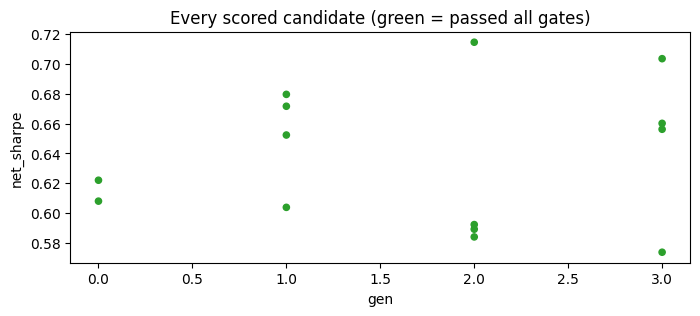

In [14]:
# the lineage is the full audit trail: one row per scored candidate
lineage = [json.loads(l) for l in
           (WORKDIR / "evolution_exec" / "lineage.jsonl").read_text().splitlines()]
lin_df = pd.DataFrame([
    {"gen": r["generation"], "op": r["operator"],
     "id": r["factor_ids"][0][:24], "selectable": r["selectable"],
     "net_sharpe": (r["objective"] or {}).get("marginal_value")}
    for r in lineage if "operator" in r])
ax = lin_df.plot.scatter(x="gen", y="net_sharpe", c=lin_df["selectable"].map(
    {True: "tab:green", False: "tab:red"}), figsize=(8, 3),
    title="Every scored candidate (green = passed all gates)")
lin_df.tail(6)


## 10. The block API: resume, SOTA view, re-score (what the joint layer consumes)

The outer joint layer (`docs/joint-evolution/DESIGN.md`) drives this loop in
*blocks*: `run(resume=True, n_generations=G)` continues from `state.json` with
`n_trials`/archive/lineage intact; `sota_executor()` is the frozen-SOTA view the
factor arm's coupling gate will receive; `rescore_archive(new_manifest)`
re-evaluates every held genome after a factor-block re-freeze — **billing the joint
ledger's look count, never `n_trials`** (a re-score is a fresh look at VAL, not a
new hypothesis).


In [15]:
resumed = ExecEvolutionLoop(cfg)
s2 = resumed.run(resume=True, n_generations=2)
print(f"resumed: generations={s2['generations']} (3 + 2), n_trials={s2['n_trials']}")

sota = resumed.sota_executor()
print("SOTA executor:", sota["executor_id"], "| objective:",
      {k: round(v, 4) for k, v in sota["objective"].items() if v is not None})

# re-freeze (v2) and deterministically re-score the whole archive
v2 = svc.freeze_signals(BOOK, out_dir=str(WORKDIR), version=2, target_horizon=1,
                        specs=[{"model": "ridge", "subset": [0, 1]},
                               {"model": "ridge", "subset": [1]}])
before = resumed.controller.n_trials
out = resumed.rescore_archive(v2["manifest_path"])
print("rescore:", out, "| n_trials unchanged:", resumed.controller.n_trials == before)


resumed: generations=5 (3 + 2), n_trials=20
SOTA executor: ex5_8_1fab | objective: {'marginal_value': 0.7476, 'independence': 0.7458, 'robustness': 0.9282, 'parsimony': -41.0, 'structural_novelty': 0.0168}


rescore: {'rescored': 20, 'failed': 0, 'archive': 9, 'kept_pool': 20, 'n_looks': 20} | n_trials unchanged: True


## Wrap-up — where this goes next

* **E3** adds the skeptic/moderator debate + RAG grounding on execution literature.
* **E4** stamps `executor_id` onto `StrategySpec`/`StrategyRecord` so deployed
  strategies reproduce the evolved book in the Architect IS-fit, the Statistician
  OOS test and the walk-forward trade loop.
* **J0–J4** wrap factor + execution evolution in the block-coordinate outer layer:
  shared SOTA state, re-freeze protocol (what `rescore_archive` exists for), the
  round-robin/bandit scheduler, the shared cross-arm N_trials ledger, and the joint
  walk-forward that produces the headline OOS numbers.

Progress tracker: `docs/execution-evolution/IMPLEMENTATION_PROGRESS.md`.
